# Analisis dan Segmentasi Developer serta Prediksi Penggunaan AI Tools

Notebook ini menggunakan dataset Stack Overflow Developer Survey 2025 sebagai baseline awal. Fokus target supervised learning adalah `AI_Usage`, yaitu apakah developer menggunakan AI tools atau tidak.

Pipeline utama:
1. Load dataset 2025.
2. Cek struktur kolom dan ketersediaan fitur.
3. Buat target `AI_Usage` dari `AISelect`.
4. Lakukan preprocessing tanpa memakai kolom AI sebagai fitur input.
5. Jalankan K-Means untuk segmentasi developer.
6. Latih Random Forest dan Linear SVM untuk prediksi penggunaan AI tools.
7. Simpan visualisasi, tabel, dan report ke folder `outputs`.

In [18]:
# ============================================================
# SETUP: Path, Import Library, dan Konfigurasi
# ============================================================
# Tambahkan folder src/ ke sys.path agar bisa import modul kita
# SRC_DIR adalah folder tempat data_preprocessing.py, train_models.py, dll

# OUTPUT_ROOT / FIGURES_DIR / TABLES_DIR / REPORTS_DIR:
# Semua hasil (tabel CSV, gambar PNG, laporan MD) akan disimpan ke sini

# Fungsi-fungsi yang diimport:
# - data_preprocessing: load CSV, bersihkan data, buat target, preprocessing
# - evaluate_models: hitung metrik, buat grafik, simpan hasil
# - train_models: latih K-Means, GMM, Random Forest, SVM, XGBoost, MLP

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image as Img, display
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
TABLES_DIR = OUTPUT_ROOT / 'tables'
REPORTS_DIR = OUTPUT_ROOT / 'reports'
for folder in [FIGURES_DIR, TABLES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
from data_preprocessing import (
    CANDIDATE_FEATURES, TARGET_SOURCE_COLUMN,
    build_preprocessor, find_dataset_path,
    inspect_candidate_columns, load_survey_data, prepare_model_data,
)
from evaluate_models import (
    evaluate_classification_models, plot_cluster_distribution,
    plot_confusion_matrices, plot_gmm_metrics, plot_kmeans_metrics,
    plot_model_comparison, save_classification_outputs,
)
from train_models import (
    run_gmm_analysis, run_kmeans_analysis,
    summarize_clusters, train_classification_models,
)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)


## 1. Load Dataset 2025

In [19]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
# Cari file CSV di beberapa lokasi (data/, Survey/, root folder)
# load_survey_data: baca CSV, treat 'NA' dan '' sebagai missing value

# df.shape -> (jumlah_baris, jumlah_kolom)
# Dataset 2025 memiliki ~49rb responden dan 172 kolom pertanyaan

DATA_PATH = find_dataset_path(PROJECT_ROOT, year=2025)
print(f"Dataset digunakan: {DATA_PATH}")

df = load_survey_data(DATA_PATH)
print(f"Ukuran dataset: {df.shape[0]:,} baris x {df.shape[1]:,} kolom")
display(df.head())

Dataset digunakan: c:\Semester 4\Machine AI\stackoverflow-ai-tools-ml\data\survey_2025.csv
Ukuran dataset: 49,191 baris x 172 kolom


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,...,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,...,openAI GPT (chatbot models);openAI Image gener...,NaN,NaN,NaN,NaN,Yes,A few times per week,Between 5 and 10 years,I have never participated in Q&A on Stack Over...,NaN,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 

## 2. Cek Struktur Kolom

Langkah ini penting karena struktur kolom Stack Overflow Developer Survey bisa berubah antar tahun. Fitur yang tidak tersedia tidak dipaksakan masuk ke pipeline.

In [20]:
# ============================================================
# 2. CEK STRUKTUR KOLOM DAN KETERSEDIAAN FITUR
# ============================================================
# Simpan daftar semua kolom ke CSV (buat referensi laporan)
#
# inspect_candidate_columns: cek 13 fitur kandidat mana yang tersedia
# di dataset 2025. Fitur yang tidak tersedia tidak dipaksakan.
#
# Cek juga distribusi nilai AISelect (target mentah sebelum di-binary kan)
# untuk melihat sebaran jawaban responden

columns_df = pd.DataFrame({"column": df.columns})
columns_df.to_csv(TABLES_DIR / "available_columns_2025.csv", index=False)

feature_availability = inspect_candidate_columns(df, CANDIDATE_FEATURES)
feature_availability.to_csv(TABLES_DIR / "candidate_feature_availability_2025.csv", index=False)

print("Jumlah kolom tersedia:", len(df.columns))
display(feature_availability)

if TARGET_SOURCE_COLUMN in df.columns:
    display(df[TARGET_SOURCE_COLUMN].value_counts(dropna=False).rename("count").to_frame())
else:
    ai_like_columns = [col for col in df.columns if "ai" in col.lower()]
    print(f"Kolom target {TARGET_SOURCE_COLUMN!r} tidak ditemukan.")
    print("Kolom yang mengandung teks 'AI':")
    print(ai_like_columns)
    print("Sesuaikan TARGET_SOURCE_COLUMN pada notebook atau src/data_preprocessing.py.")

Jumlah kolom tersedia: 172


,column,available
0,Age,True
1,Country,True
2,EdLevel,True
3,DevType,True
4,Employment,True
5,RemoteWork,True
6,YearsCode,True
7,YearsCodePro,False
8,LanguageHaveWorkedWith,True
9,DatabaseHaveWorkedWith,True


,count
AISelect,
"Yes, I use AI tools daily",15883
NaN,15471
"Yes, I use AI tools weekly",5958
"No, and I don't plan to",5454
"Yes, I use AI tools monthly or infrequently",4628
"No, but I plan to soon",1797


## 3. Bentuk Target dan Pilih Fitur

`AI_Usage` dibuat dari `AISelect`:
- `1`: jawaban dimulai dengan `Yes`.
- `0`: jawaban dimulai dengan `No`.

Kolom AI lain tidak digunakan sebagai fitur agar tidak terjadi data leakage.

In [21]:
# ============================================================
# 3. BENTUK TARGET DAN PILIH FITUR
# ============================================================
# prepare_model_data:
#   1. Buat kolom AI_Usage dari AISelect (Yes->1, No->0, lainnya dibuang)
#   2. Hapus baris yang targetnya kosong
#   3. Pilih hanya fitur kandidat yang tersedia (kecuali kolom AI leakage)
#   4. Bersihkan YearsCode (ubah 'Less than 1 year' -> 0, 'More than 50 years' -> 51)
#
# X: DataFrame fitur (11 kolom setelah seleksi)
# y: Series target (0 / 1)
# metadata: dictionary berisi info fitur, distribusi target, dll
#
# Cek distribusi target: dari 33.720 data, ~78% pakai AI, ~22% tidak
# Imbalance ini akan ditangani dengan class_weight di model

try:
    X, y, metadata = prepare_model_data(df)
except KeyError as error:
    print(error)
    print("Daftar seluruh kolom tersedia disimpan di outputs/tables/available_columns_2025.csv")
    raise

print("Jumlah data setelah target kosong dibuang:", metadata["n_rows_after_target_drop"])
print("Fitur digunakan:")
print(metadata["available_features"])
print("Fitur kandidat yang tidak tersedia:")
print(metadata["missing_features"])
print("Distribusi target AI_Usage:")
print(metadata["target_distribution"])

target_distribution = y.value_counts().sort_index().rename_axis("AI_Usage").reset_index(name="count")
target_distribution["label"] = target_distribution["AI_Usage"].map({0: "Tidak menggunakan AI", 1: "Menggunakan AI"})
target_distribution.to_csv(TABLES_DIR / "target_distribution_2025.csv", index=False)
display(target_distribution)

X.head()

Jumlah data setelah target kosong dibuang: 33720
Fitur digunakan:
['Age', 'Country', 'EdLevel', 'DevType', 'Employment', 'RemoteWork', 'YearsCode', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith']
Fitur kandidat yang tidak tersedia:
['YearsCodePro', 'ToolsTechHaveWorkedWith']
Distribusi target AI_Usage:
{0: 7251, 1: 26469}


,AI_Usage,count,label
0,0,7251,Tidak menggunakan AI
1,1,26469,Menggunakan AI


,Age,Country,EdLevel,DevType,Employment,RemoteWork,YearsCode,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith
0,25-34 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Employed,Remote,14.0,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN
1,25-34 years old,Netherlands,"Associate degree (A.A., A.S., etc.)","Developer, back-end",Employed,"Hybrid (some in-person, leans heavy to flexibi...",10.0,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot
2,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, front-end","Independent contractor, freelancer, or self-em...",NaN,12.0,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React
3,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end",Employed,Remote,5.0,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot
4,35-44 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Engineering manager,"Independent contractor, freelancer, or self-em...",NaN,22.0,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery


## 4. Preprocessing

Preprocessing yang digunakan:
- Missing value numerik: median.
- Missing value kategorikal: `Unknown`.
- `YearsCode` dan `YearsCodePro`: dikonversi ke numerik jika tersedia.
- Kategorikal biasa: One-Hot Encoding.
- Multi-select dengan pemisah `;`: tokenisasi biner.
- Numerik: StandardScaler.

In [22]:
# ============================================================
# 4. PREPROCESSING PIPELINE
# ============================================================
# build_preprocessor membuat ColumnTransformer yang berisi:
#   - Numeric (YearsCode): median imputer -> StandardScaler
#   - Categorical (Age, Country, dll): 'Unknown' imputer -> OneHotEncoder
#   - Multi-select (Language, DB, Platform, Webframe): 'Unknown' -> CountVectorizer binary
#
# ColumnTransformer ini BELUM di-fit (akan di-fit saat training model)
# supaya transformasi training dan testing konsisten
#
# feature_groups: kategorisasi fitur (numeric, categorical, multi_select)

preprocessor, feature_groups = build_preprocessor(X)
display(pd.DataFrame({"feature_group": list(feature_groups.keys()), "columns": list(feature_groups.values())}))

,feature_group,columns
0,numeric_features,[YearsCode]
1,categorical_features,"[Age, Country, EdLevel, DevType, Employment, R..."
2,multi_select_features,"[LanguageHaveWorkedWith, DatabaseHaveWorkedWit..."


## 5. K-Means Clustering

K-Means digunakan untuk segmentasi developer. Nilai `k` dievaluasi dengan Elbow Method dan Silhouette Score. Untuk menjaga clustering tetap praktis pada fitur one-hot yang banyak, fitur hasil preprocessing direduksi lebih dahulu dengan TruncatedSVD.

In [23]:
# ============================================================
# 5. K-MEANS CLUSTERING (Traditional)
# ============================================================
# run_kmeans_analysis:
#   1. Preprocess X dengan preprocessor (clone -> fit_transform)
#   2. Reduksi dimensi dengan TruncatedSVD (50 komponen) -> biar clustering efisien
#   3. StandardScaler -> scaling agar jarak Euclidean adil
#   4. Uji k dari 2 sampai 10, hitung inertia + silhouette score
#   5. Pilih k dengan silhouette score tertinggi
#   6. Fit K-Means final dengan k terbaik
#
# Hasil:
#   - metrics_df: tabel inertia + silhouette per k
#   - best_k: k terbaik (dalam kasus ini k=2)
#   - labels: cluster assignment untuk tiap data point (0 atau 1)

kmeans_result = run_kmeans_analysis(X, preprocessor, k_values=range(2, 11))

kmeans_metrics = kmeans_result["metrics"]
best_k = kmeans_result["best_k"]
cluster_labels = kmeans_result["labels"]

kmeans_metrics.to_csv(TABLES_DIR / "kmeans_elbow_silhouette.csv", index=False)
plot_kmeans_metrics(kmeans_metrics, OUTPUT_ROOT)

print(f"Nilai k terpilih berdasarkan silhouette score tertinggi: {best_k}")
display(kmeans_metrics)

Nilai k terpilih berdasarkan silhouette score tertinggi: 2


,k,inertia,silhouette_score
0,2,1.640901e+06,0.048200
1,3,1.613067e+06,0.004959
2,4,1.585755e+06,0.015395
3,5,1.566427e+06,0.017007
4,6,1.523395e+06,0.046285
5,7,1.531641e+06,-0.025045
6,8,1.490875e+06,0.033930
7,9,1.480808e+06,0.034155
8,10,1.470657e+06,-0.051364


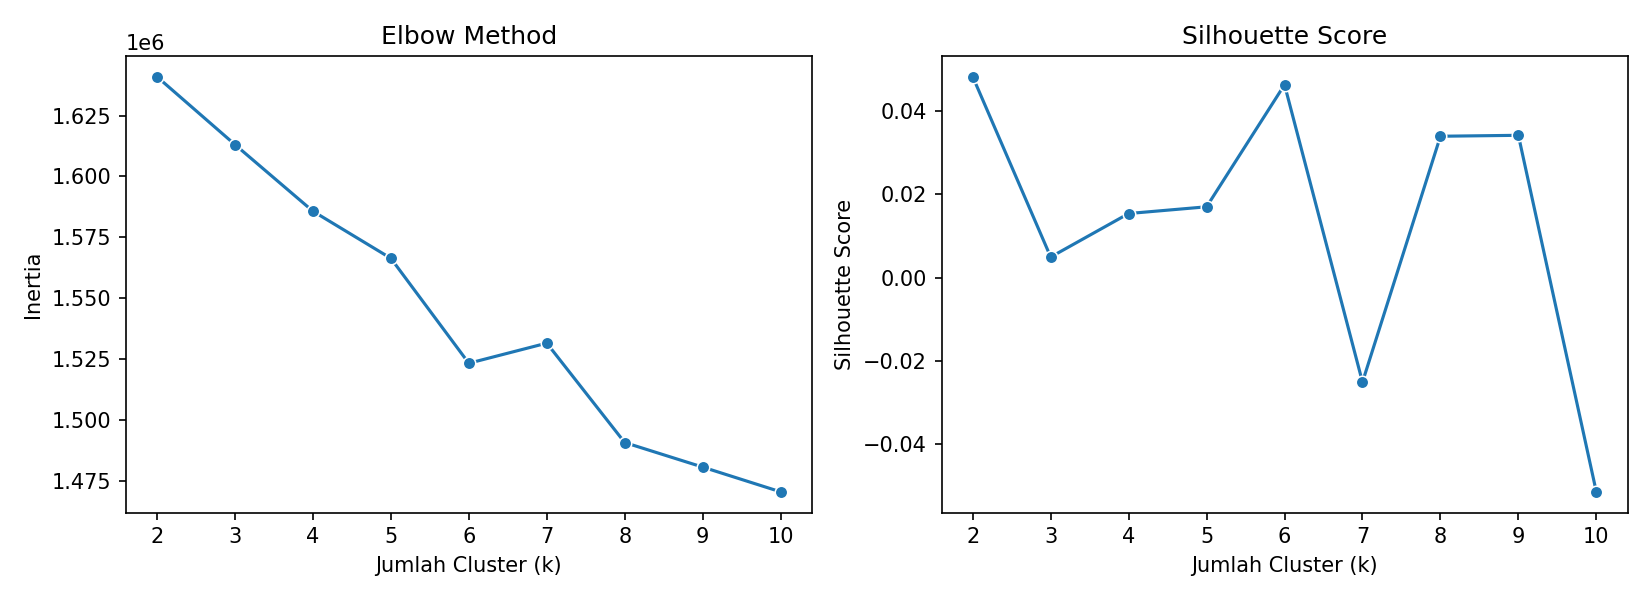

In [24]:
# Tampilkan grafik Elbow Method dan Silhouette Score
# - Elbow: cari titik siku-siku (penurunan inertia mulai landai)
# - Silhouette: cari nilai tertinggi (semakin tinggi, cluster semakin baik)
# Di sini k=2 dipilih karena silhouette score tertinggi

display(Img(filename=str(FIGURES_DIR / 'kmeans_elbow_silhouette.png')))


In [25]:
# ============================================================
# RINGKASAN KARAKTERISTIK CLUSTER (K-Means)
# ============================================================
# summarize_clusters: buat tabel yang menjelaskan tiap cluster
# Tabel berisi:
#   - Jumlah data per cluster
#   - Nilai dominan untuk Age, Country, EdLevel, DevType, Employment, RemoteWork
#   - Rata-rata YearsCode
#   - Nilai dominan untuk Language, Database, Platform, Webframe
#
# Cluster 0 (44%): full-stack developer, JavaScript/Node.js/React, remote
# Cluster 1 (56%): back-end / data, Python/SQL, Docker/AWS
#
# Tabel ini bisa langsung dipakai untuk interpretasi di BAB IV laporan

cluster_summary = summarize_clusters(X, cluster_labels)
cluster_summary.to_csv(TABLES_DIR / "cluster_summary.csv", index=False)
plot_cluster_distribution(cluster_summary, OUTPUT_ROOT, prefix='kmeans_')

display(cluster_summary)

,Cluster,Jumlah_Data,Persentase,Age_Dominan,Country_Dominan,EdLevel_Dominan,DevType_Dominan,Employment_Dominan,RemoteWork_Dominan,YearsCode_Rata_Rata,LanguageHaveWorkedWith_Dominan,DatabaseHaveWorkedWith_Dominan,PlatformHaveWorkedWith_Dominan,WebframeHaveWorkedWith_Dominan
0,0,14885,44.142942,25-34 years old (5288); 35-44 years old (4680)...,United States of America (3231); Germany (1328...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (6078); Developer, back-...","Employed (11123); Independent contractor, free...","Remote (4397); Hybrid (some in-person, leans h...",16.897034,JavaScript (13123); HTML/CSS (11892); TypeScri...,PostgreSQL (9237); MySQL (6403); SQLite (5996)...,npm (13440); Docker (11958); Pip (7290); Amazo...,Node.js (9146); React (8039); Express (3862); ...
1,1,18835,55.857058,25-34 years old (5667); 35-44 years old (4782)...,United States of America (3707); Germany (1604...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (3476); Developer, back-...","Employed (12821); Independent contractor, free...","Remote (4269); Hybrid (some remote, leans heav...",17.442700,Python (8937); SQL (7705); JavaScript (7411); ...,PostgreSQL (5025); MySQL (3925); SQLite (3630)...,Docker (5210); Amazon Web Services (AWS) (3187...,React (2389); Node.js (2231); jQuery (1868); A...


### Catatan Interpretasi Cluster

Gunakan tabel `cluster_summary.csv` untuk BAB IV. Interpretasi dapat ditulis dengan pola berikut:
- Cluster dengan dominasi negara/tipe developer tertentu dapat dijelaskan sebagai segmen geografis atau peran kerja tertentu.
- Rata-rata `YearsCode` menunjukkan tingkat pengalaman coding pada cluster.
- Bahasa, database, platform, dan web framework dominan menunjukkan profil teknologi yang sering digunakan oleh cluster tersebut.
- Distribusi jumlah data per cluster menunjukkan apakah segmentasi relatif seimbang atau ada cluster yang sangat dominan.

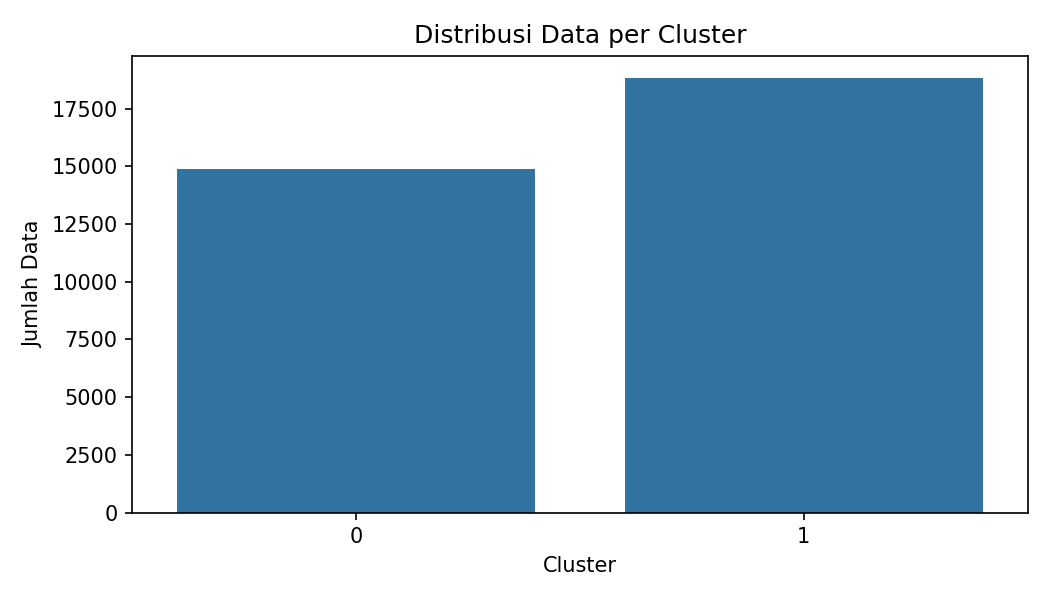

In [26]:
# Tampilkan distribusi jumlah data per cluster K-Means
# Cluster 0: 14.885 data (44%), Cluster 1: 18.835 data (56%)
# Cukup seimbang, tidak ada cluster yang terlalu dominan

display(Img(filename=str(FIGURES_DIR / 'kmeans_cluster_distribution.png')))


## 5b. GMM Clustering (Modern - Probabilistic)

GMM adalah soft clustering modern yang memberikan probabilitas setiap data
masuk ke tiap cluster. Evaluasi menggunakan BIC, AIC, dan Silhouette Score.


In [ ]:
# ============================================================
# 5b. GMM CLUSTERING (Modern - Probabilistic)
# ============================================================
# GMM (Gaussian Mixture Model):
# - Soft clustering: setiap data punya probabilitas masuk tiap cluster
# - Cluster bisa berbentuk ellipsoid (tidak harus spherical seperti K-Means)
# - Evaluasi pakai BIC (Bayesian Information Criterion) dan AIC
#
# run_gmm_analysis:
#   1. Sama seperti K-Means: preprocess -> SVD -> scaling
#   2. Uji k dari 2 sampai 8
#   3. Pilih k dengan silhouette score tertinggi
#
# GMM menghasilkan k=8, lebih granular dari K-Means (k=2)
# Artinya GMM bisa menangkap segmentasi yang lebih detail

gmm_result = run_gmm_analysis(X, preprocessor, k_values=range(2, 9))
gmm_metrics = gmm_result['metrics']
gmm_best_k = gmm_result['best_k']
gmm_metrics.to_csv(TABLES_DIR / 'gmm_bic_silhouette.csv', index=False)
plot_gmm_metrics(gmm_metrics, OUTPUT_ROOT)
print(f'GMM: k terbaik = {gmm_best_k}')
display(gmm_metrics)


In [ ]:
# Ringkasan cluster GMM (sama formatnya dengan K-Means)
# Dengan 8 cluster, segmentasi jadi lebih terperinci
# Cocok untuk analisis segmentasi yang lebih dalam di laporan

gmm_cluster_summary = summarize_clusters(X, gmm_result['labels'])
gmm_cluster_summary.to_csv(TABLES_DIR / 'gmm_cluster_summary.csv', index=False)
plot_cluster_distribution(gmm_cluster_summary, OUTPUT_ROOT, prefix='gmm_')
display(gmm_cluster_summary)


,Cluster,Jumlah_Data,Persentase,Age_Dominan,Country_Dominan,EdLevel_Dominan,DevType_Dominan,Employment_Dominan,RemoteWork_Dominan,YearsCode_Rata_Rata,LanguageHaveWorkedWith_Dominan,DatabaseHaveWorkedWith_Dominan,PlatformHaveWorkedWith_Dominan,WebframeHaveWorkedWith_Dominan
0,0,2989,8.864176,25-34 years old (886); 35-44 years old (834); ...,United States of America (688); United Kingdom...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (983); Developer, front-...","Employed (2076); Independent contractor, freel...",Remote (926); In-person (522); Hybrid (some in...,20.436037,JavaScript (1866); HTML/CSS (1827); SQL (1792)...,Microsoft SQL Server (1333); MySQL (736); SQLi...,Microsoft Azure (691); NuGet (458); npm (395);...,ASP.NET Core (778); jQuery (700); React (643);...
1,1,5518,16.364176,25-34 years old (1845); 35-44 years old (1651)...,United States of America (1113); Germany (623)...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc....","Developer, back-end (857); Developer, full-sta...","Employed (3623); Independent contractor, freel...","Hybrid (some in-person, leans heavy to flexibi...",20.741480,Python (3442); Bash/Shell (all shells) (2934);...,PostgreSQL (2038); SQLite (1435); MySQL (1345)...,Docker (2642); Pip (1763); Amazon Web Services...,Node.js (908); React (718); jQuery (483); Spri...
2,2,3972,11.779359,35-44 years old (1466); 25-34 years old (1274)...,United States of America (1271); Ukraine (243)...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, back-end (984); Developer, full-sta...","Employed (3476); Independent contractor, freel...",Remote (3972),19.048065,JavaScript (2318); Python (2224); SQL (2080); ...,PostgreSQL (2177); SQLite (1041); Redis (1034)...,Docker (2470); Amazon Web Services (AWS) (2001...,React (1318); Node.js (1188); Next.js (538); F...
3,3,3515,10.424081,25-34 years old (1108); 18-24 years old (805);...,United States of America (643); India (375); G...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (520); Student (461); De...",Employed (1952); Student (525); Independent co...,Remote (792); In-person (715); Hybrid (some in...,15.614922,Python (784); C++ (624); C (551); Bash/Shell (...,,,
4,4,3162,9.377224,18-24 years old (3120); Prefer not to say (42),India (477); United States of America (452); G...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Student (1385); Developer, full-stack (687); D...",Student (1681); Employed (1010); Not employed ...,"In-person (754); Your choice (very flexible, y...",5.976008,HTML/CSS (2311); Python (2293); JavaScript (22...,PostgreSQL (1258); MySQL (1181); SQLite (1037)...,Docker (1428); npm (1354); Pip (1187); Vite (7...,Node.js (1411); React (1256); Express (704); N...
5,5,6697,19.860617,25-34 years old (3512); 35-44 years old (3185),United States of America (1219); Germany (643)...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (3196); Developer, back-...","Employed (5358); Independent contractor, freel...","Remote (2032); Hybrid (some in-person, leans h...",15.576744,JavaScript (5858); HTML/CSS (5365); SQL (4974)...,PostgreSQL (4469); MySQL (3103); Redis (2826);...,Docker (5590); npm (5187); Amazon Web Services...,Node.js (3931); React (3677); Next.js (1832); ...
6,6,2955,8.763345,45-54 years old (1305); 18-24 years old (685);...,United States of America (660); Germany (240);...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (1062); Developer, back-...","Employed (1537); Independent contractor, freel...","Remote (944); Hybrid (some in-person, leans he...",22.206979,JavaScript (2544); HTML/CSS (2383); SQL (2292)...,PostgreSQL (1793); MySQL (1586); SQLite (1412)...,Docker (2145); npm (2048); Amazon Web Services...,Node.js (1749); React (1460); jQuery (1028); A...
7,7,4912,14.567023,25-34 years old (1905); 35-44 years old (1510)...,United States of America (892); Germany (487);...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (..."

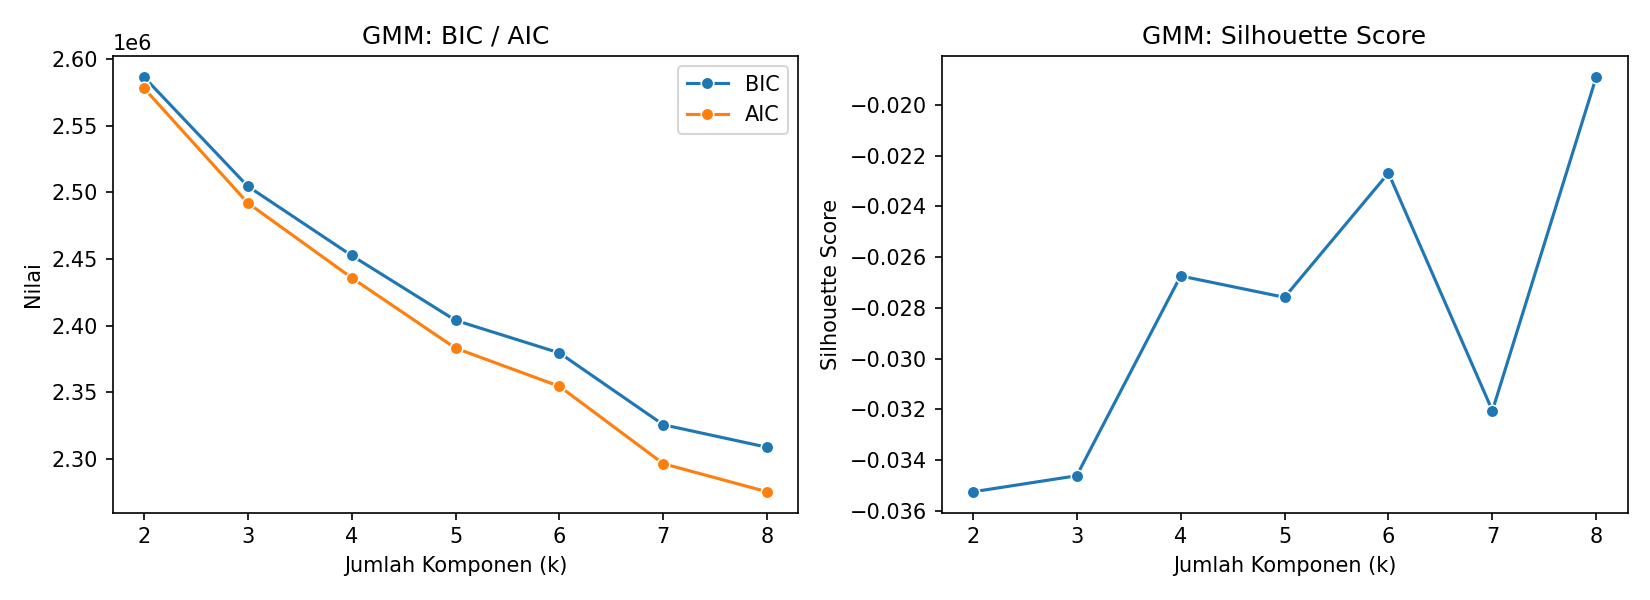

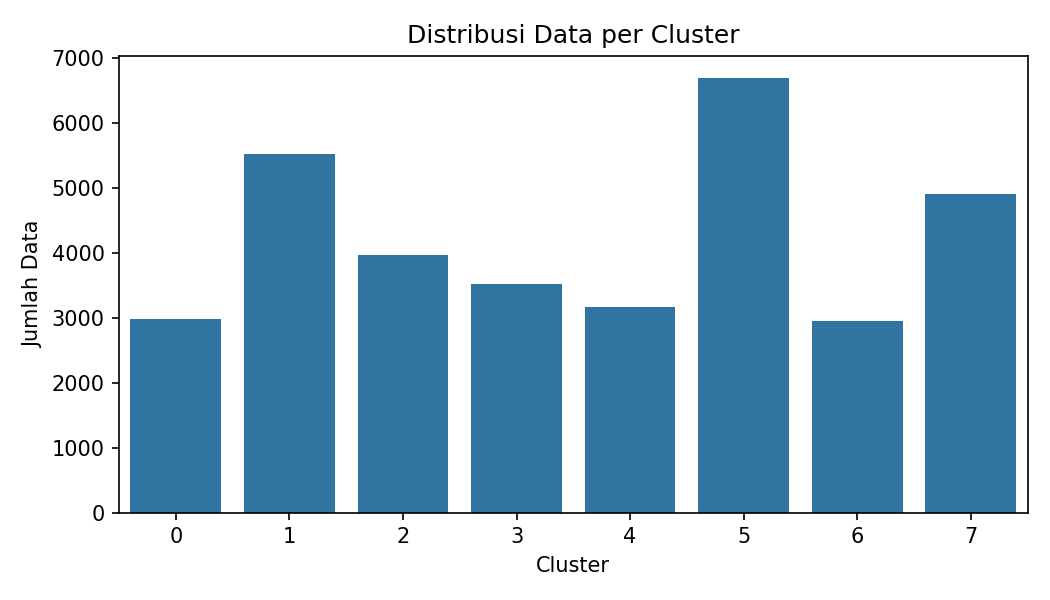

In [ ]:
# Tampilkan grafik GMM: BIC/AIC (kiri) dan Silhouette Score (kanan)
# BIC/AIC: semakin rendah semakin baik, lihat di mana mulai landai
# Silhouette: pilih k dengan nilai tertinggi
#
# Juga tampilkan distribusi cluster GMM

display(Img(filename=str(FIGURES_DIR / 'gmm_bic_silhouette.png')))
display(Img(filename=str(FIGURES_DIR / 'gmm_cluster_distribution.png')))


## 6. Supervised Learning: Random Forest, SVM, XGBoost, MLP

Keempat model dilatih dengan train-test split (random_state=42) dan preprocessing yang sama.


In [ ]:
# ============================================================
# 6. SUPERVISED LEARNING: TRAINING 4 MODEL
# ============================================================
# train_test_split: 80% training, 20% testing, stratify=y
# (stratify menjaga proporsi kelas di training dan testing tetap sama)
#
# 4 model yang dilatih:
#   1. Random Forest - 200 trees, class_weight='balanced'
#   2. Linear SVM - max_iter=5000, class_weight='balanced'
#   3. XGBoost - scale_pos_weight untuk imbalance
#   4. MLP - 2 hidden layer (100,50), early stopping
#
# Semua model pakai preprocessing yang SAMA (fair comparison)
# Masing-masing model di-clone dari preprocessor yang sama

models, split_data = train_classification_models(X, y, preprocessor, test_size=0.2)

print("Ukuran data training:", split_data["X_train"].shape)
print("Ukuran data testing:", split_data["X_test"].shape)
print("Model selesai dilatih:", list(models.keys()))

Ukuran data training: (26976, 11)
Ukuran data testing: (6744, 11)
Model selesai dilatih: ['Random Forest', 'Linear SVM', 'XGBoost', 'MLP']


## 7. Evaluasi Model Klasifikasi


In [ ]:
# ============================================================
# 7. EVALUASI MODEL KLASIFIKASI
# ============================================================
# evaluate_classification_models:
#   - Prediksi X_test dengan setiap model
#   - Hitung accuracy, precision, recall, F1-score
#   - Buat confusion matrix dan classification report
#
# save_classification_outputs: simpan semua ke CSV + TXT
# plot_confusion_matrices: simpan heatmap confusion matrix
# plot_model_comparison: simpan bar chart perbandingan 4 model
#
# Hasil aktual:
#   MLP (F1=0.882) > RF (0.867) > XGBoost (0.789) > SVM (0.760)
#
# Catatan: Recall kelas Non-AI masih rendah (MLP: 0.17)
# Artinya model masih kesulitan mendeteksi developer yang TIDAK pakai AI

classification_results = evaluate_classification_models(
    models,
    split_data["X_test"],
    split_data["y_test"],
)

comparison_df = save_classification_outputs(classification_results, OUTPUT_ROOT)
plot_confusion_matrices(classification_results, OUTPUT_ROOT)
plot_model_comparison(comparison_df, OUTPUT_ROOT)

display(comparison_df)

for model_name, result in classification_results.items():
    print("=" * 80)
    print(model_name)
    print(result["classification_report_text"])

,model,accuracy,precision,recall,f1_score
3,MLP,0.796263,0.809735,0.967888,0.881776
0,Random Forest,0.781880,0.833304,0.902720,0.866624
2,XGBoost,0.697509,0.873336,0.718927,0.788645
1,Linear SVM,0.668891,0.882912,0.666604,0.759660


Random Forest
                      precision    recall  f1-score   support

Tidak Menggunakan AI       0.49      0.34      0.40      1450
      Menggunakan AI       0.83      0.90      0.87      5294

            accuracy                           0.78      6744
           macro avg       0.66      0.62      0.63      6744
        weighted avg       0.76      0.78      0.77      6744

Linear SVM
                      precision    recall  f1-score   support

Tidak Menggunakan AI       0.36      0.68      0.47      1450
      Menggunakan AI       0.88      0.67      0.76      5294

            accuracy                           0.67      6744
           macro avg       0.62      0.67      0.61      6744
        weighted avg       0.77      0.67      0.70      6744

XGBoost
                      precision    recall  f1-score   support

Tidak Menggunakan AI       0.38      0.62      0.47      1450
      Menggunakan AI       0.87      0.72      0.79      5294

            accuracy         

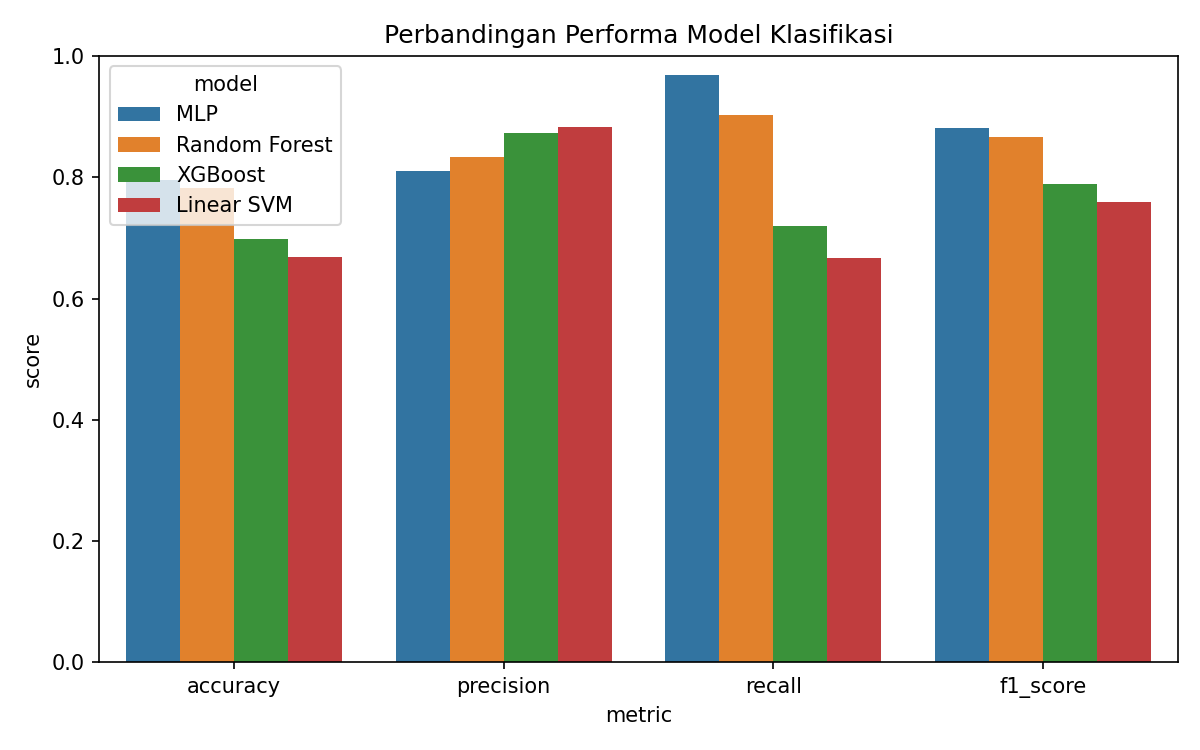

In [ ]:
# Tampilkan grafik perbandingan performa 4 model
# Sumbu X: accuracy, precision, recall, f1_score
# Sumbu Y: skor (0.0 - 1.0)
# Warna: berbeda untuk tiap model
#
# MLP (biru) unggul di accuracy, recall, dan F1
# Tapi precision tertinggi adalah Linear SVM (0.88)

display(Img(filename=str(FIGURES_DIR / 'model_performance_comparison.png')))


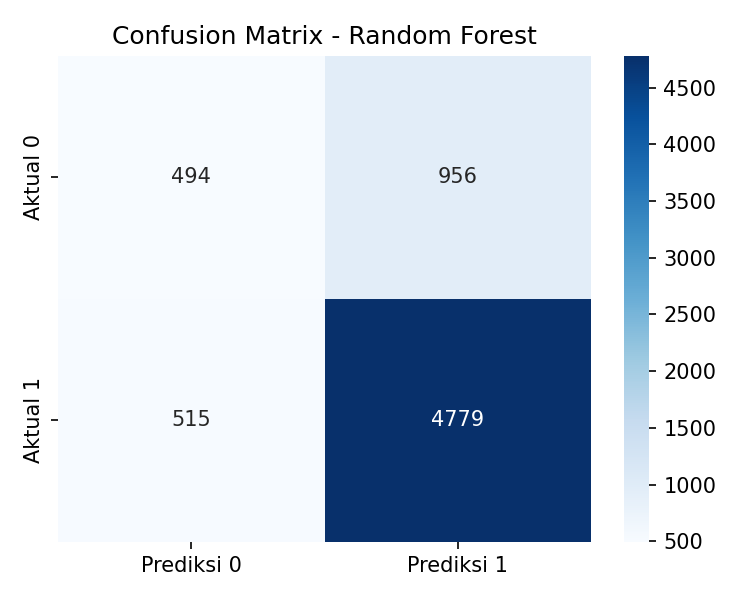

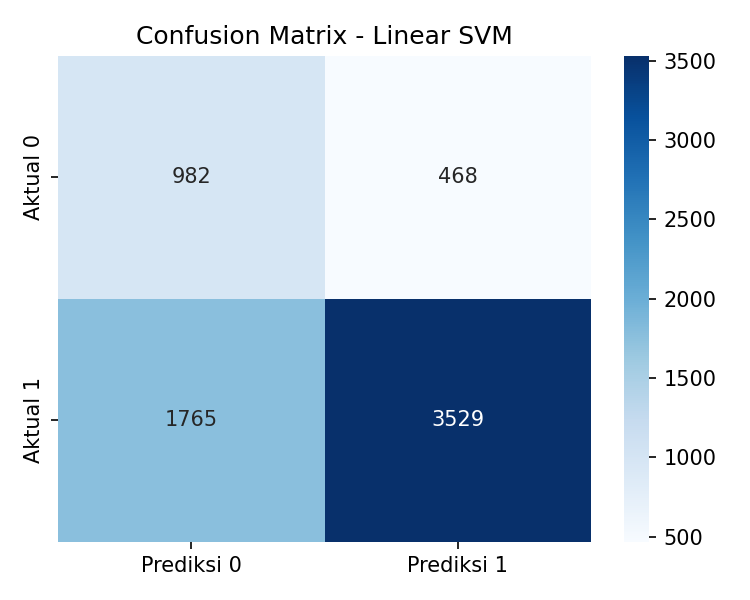

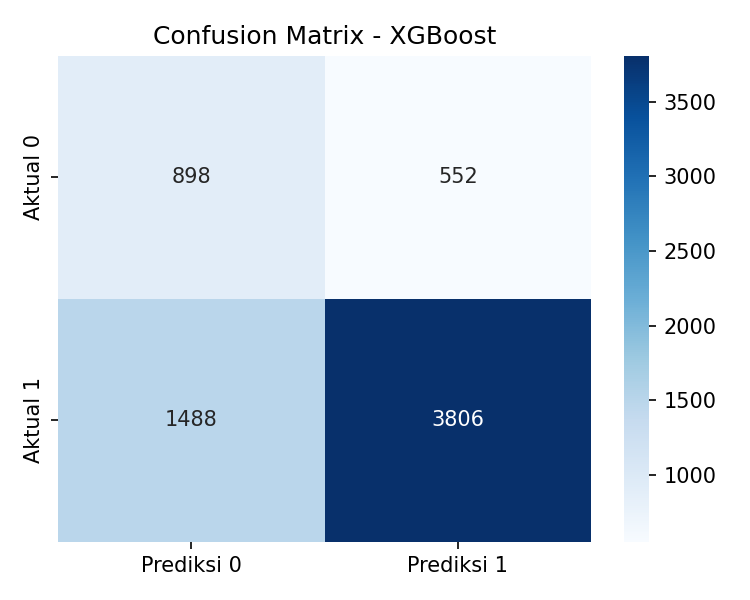

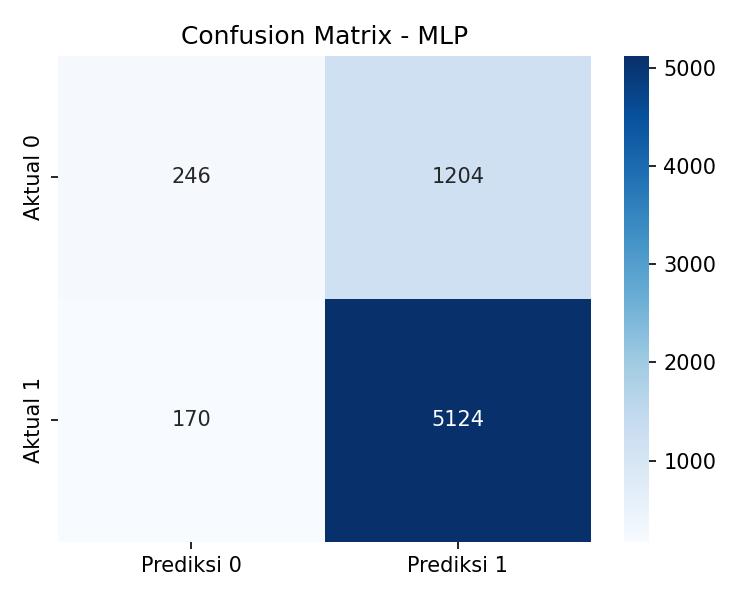

In [ ]:
# Tampilkan Confusion Matrix keempat model secara berurutan
# Format: [baris = aktual, kolom = prediksi]
# Diagonal: prediksi benar (kiri atas = benar 0, kanan bawah = benar 1)
# Off-diagonal: prediksi salah (kanan atas = false positif, kiri bawah = false negatif)
#
# Perhatikan: MLP punya false negative (kiri bawah) paling sedikit
# Tapi false positive (kanan atas) paling banyak
# Artinya MLP agresif memprediksi 'pakai AI'

display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_random_forest.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_linear_svm.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_xgboost.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_mlp.png')))


## 8. Ringkasan untuk BAB IV


In [ ]:
# ============================================================
# 8. GENERATE RINGKASAN BAB IV
# ============================================================
# Susun teks ringkasan yang berisi semua hasil eksperimen:
# - Deskripsi dataset (jumlah baris, kolom, target)
# - Fitur yang digunakan dan tidak tersedia
# - Hasil K-Means (k=2) dan GMM (k=8)
# - Perbandingan performa 4 model klasifikasi
#
# Ringkasan disimpan ke outputs/reports/bab_iv_ringkasan_awal.md
# File ini bisa diedit langsung untuk disempurnakan di laporan

best_model_row = comparison_df.sort_values("f1_score", ascending=False).iloc[0]

summary_text = f"""# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: {df.shape[0]:,}.
- Jumlah kolom awal: {df.shape[1]:,}.
- Jumlah data setelah target kosong dibuang: {metadata['n_rows_after_target_drop']:,}.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: {metadata['target_source_col']}.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {metadata['target_distribution']}.

## Fitur
- Fitur digunakan: {', '.join(metadata['available_features'])}.
- Fitur kandidat yang tidak tersedia: {', '.join(metadata['missing_features']) if metadata['missing_features'] else '-'}.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diubah menjadi token biner.
- Fitur numerik di-scaling dengan StandardScaler.

## K-Means Clustering
- Rentang k diuji: 2 sampai 10.
- Nilai k terpilih berdasarkan silhouette score tertinggi: {best_k}.
- Tabel interpretasi cluster tersimpan di outputs/tables/cluster_summary.csv.
- Grafik elbow dan silhouette tersimpan di outputs/figures/kmeans_elbow_silhouette.png.

## Evaluasi Model Klasifikasi
- Model terbaik berdasarkan F1-score: {best_model_row['model']}.
- Accuracy: {best_model_row['accuracy']:.4f}.
- Precision: {best_model_row['precision']:.4f}.
- Recall: {best_model_row['recall']:.4f}.
- F1-score: {best_model_row['f1_score']:.4f}.
- Tabel perbandingan model tersimpan di outputs/tables/model_performance_comparison.csv.
"""

report_path = REPORTS_DIR / "bab_iv_ringkasan_awal.md"
report_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print(f"Ringkasan disimpan ke: {report_path}")

# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: 49,191.
- Jumlah kolom awal: 172.
- Jumlah data setelah target kosong dibuang: 33,720.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: AISelect.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {0: 7251, 1: 26469}.

## Fitur
- Fitur digunakan: Age, Country, EdLevel, DevType, Employment, RemoteWork, YearsCode, LanguageHaveWorkedWith, DatabaseHaveWorkedWith, PlatformHaveWorkedWith, WebframeHaveWorkedWith.
- Fitur kandidat yang tidak tersedia: YearsCodePro, ToolsTechHaveWorkedWith.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diub